Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


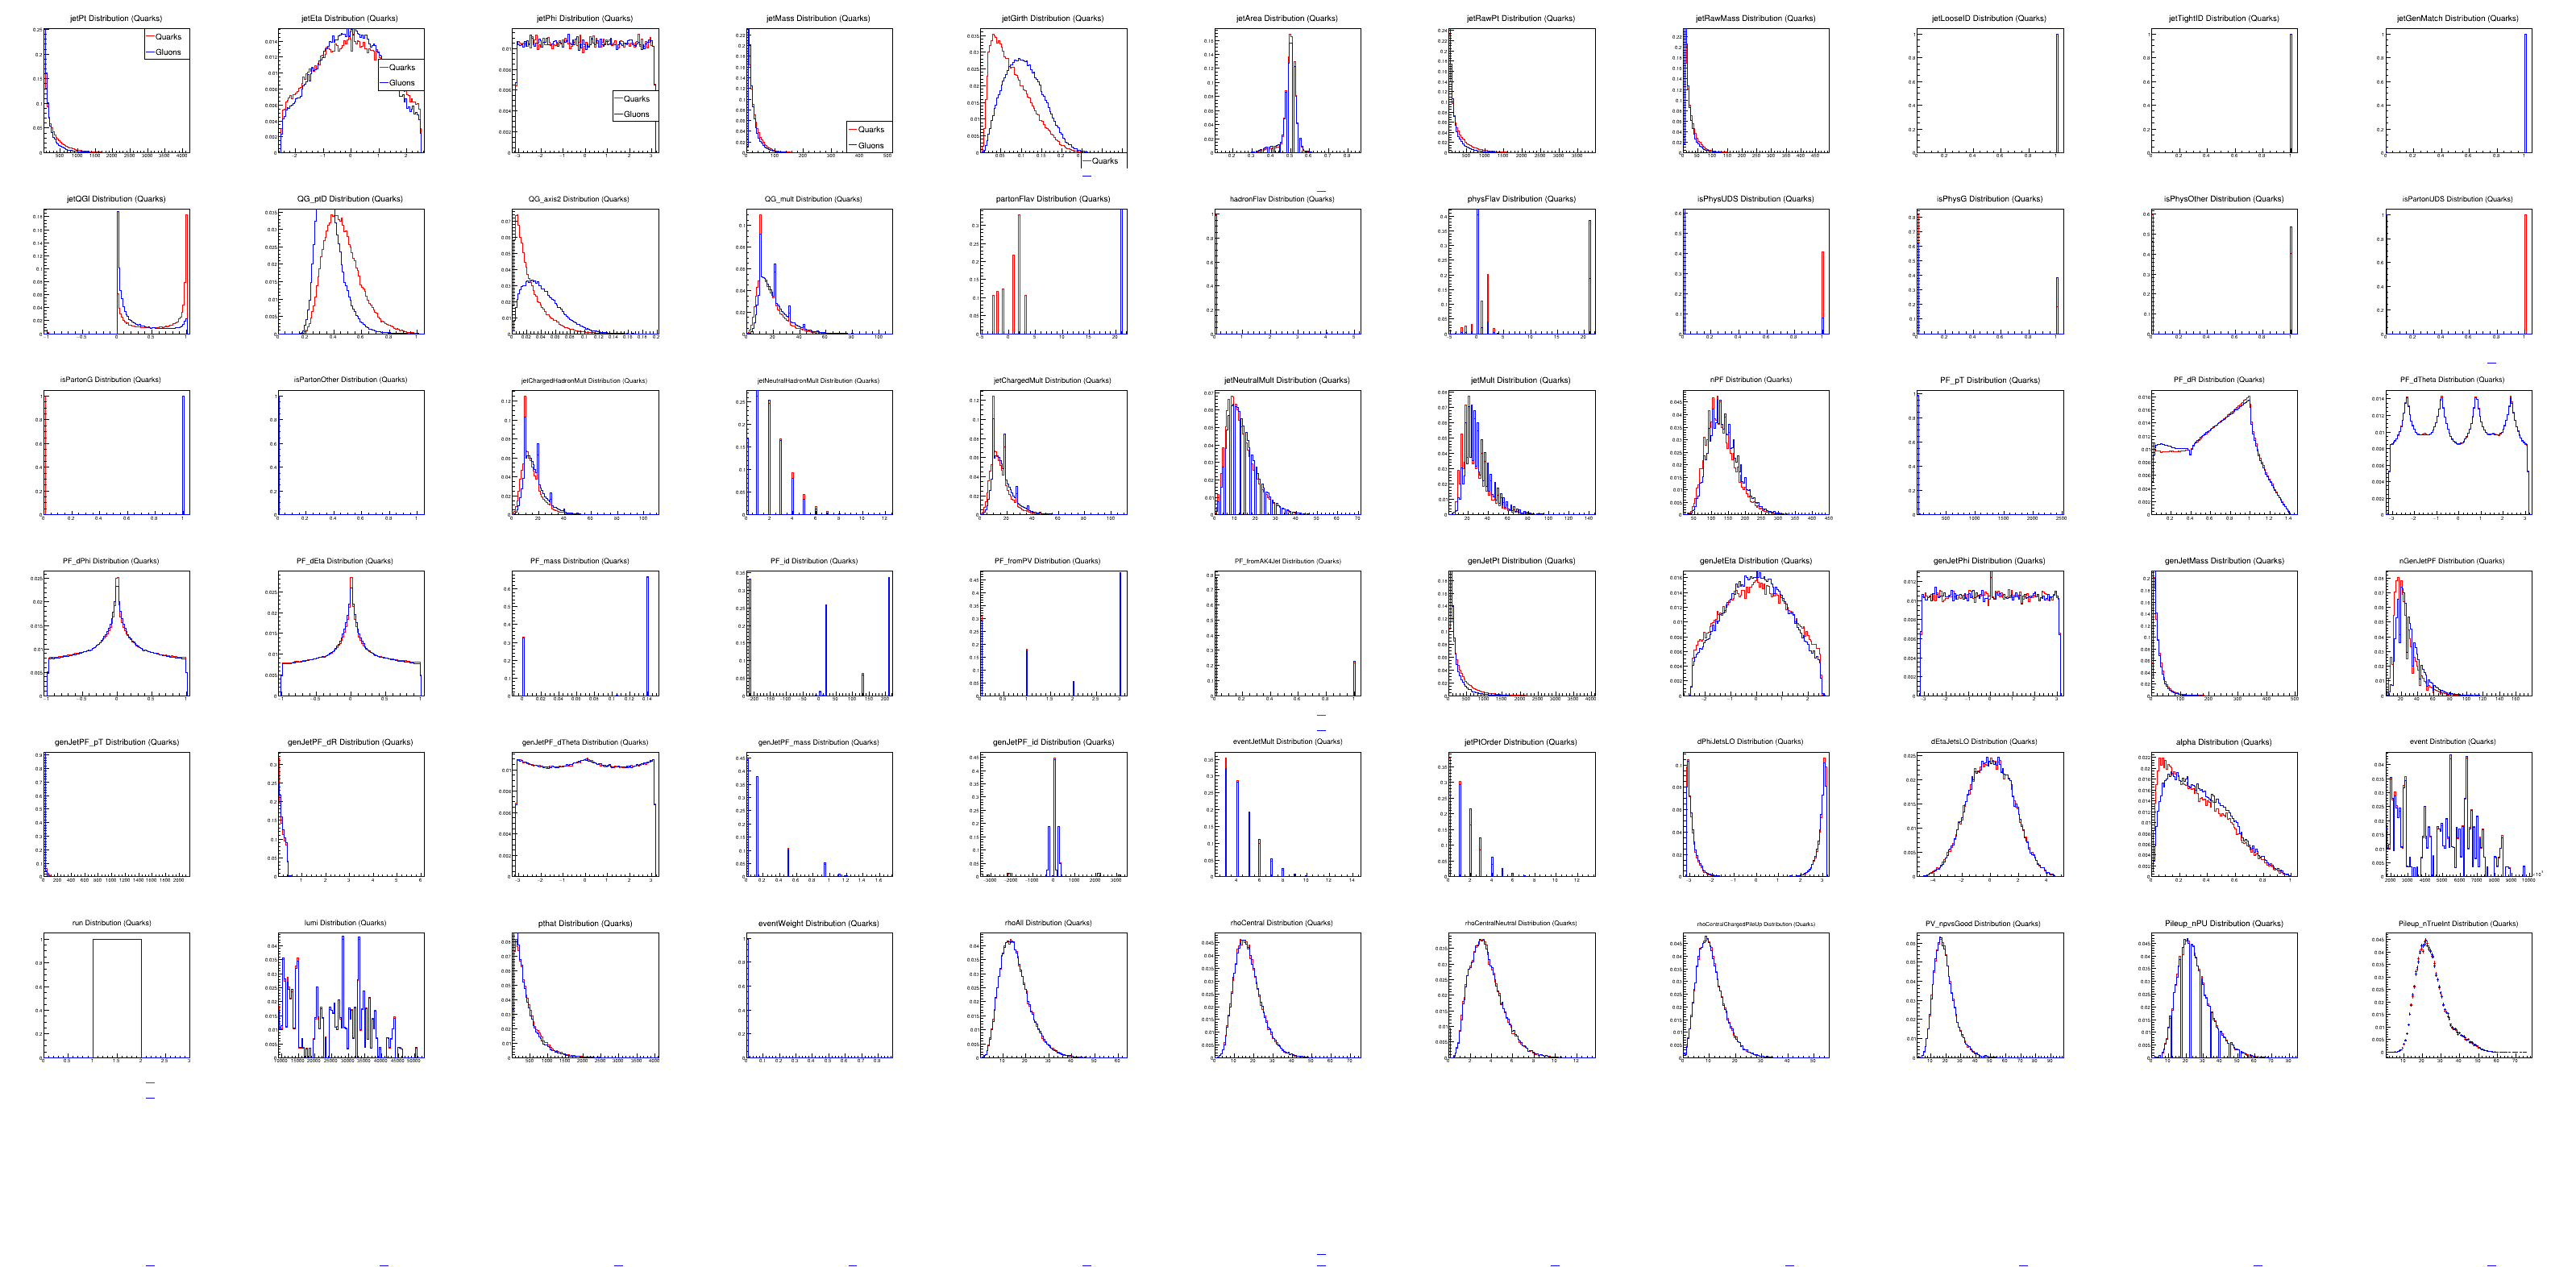

In [10]:
#Programa para graficar histogramas utilizando archivos .root

import ROOT

#Se abre el archivo con el camino hacia el archivo especificado

filepath = "/home/rizz/Downloads/JetNtuple_RunIISummer16_13TeV_MC_111.root"
f = ROOT.TFile.Open(filepath)

#Se define t como el arbol que contiene los datos de los jets, denominado como arbol.
t = f.Get("AK4jets/jetTree")

#Obtener nombres de las variables
column_names = [branch.GetName() for branch in t.GetListOfBranches()]

#Crear un canvas en root, se recomienda 3200x1600
c = ROOT.TCanvas("c", "Jet Histograms", 3200, 1600)
c.Divide(11, 7)

#Se almacenan los valores minimos y maximos para cada variable.
min_values = {}
max_values = {}
for column_name in column_names:
    min_values[column_name] = t.GetMinimum(column_name)
    max_values[column_name] = t.GetMaximum(column_name)

#Se define un array vacio para almacenar los histogramas
histograms = []  
#Titulos de los histogramas
legends = []  

#Loop para graficar todas las variables de un archivo .root
for i, column_name in enumerate(column_names):
    c.cd(i + 1)
    h_quark = ROOT.TH1F("h_" + column_name + "_quark", column_name + " Distribution (Quarks)", 100, min_values[column_name]*1.05, max_values[column_name]*1.05)
    h_gluon = ROOT.TH1F("h_" + column_name + "_gluon", column_name + " Distribution (Gluons)", 100, min_values[column_name]*1.05, max_values[column_name]*1.05)
    t.Draw(column_name + ">>h_" + column_name + "_quark", "isPartonUDS == 1", "HIST")
    t.Draw(column_name + ">>h_" + column_name + "_gluon", "isPartonG == 1", "HIST SAME")
    h_quark.SetLineColor(ROOT.kRed)
    h_gluon.SetLineColor(ROOT.kBlue)
    h_quark.SetStats(0)
    h_gluon.SetStats(0)
    legend = ROOT.TLegend(0.65, 0.7 - i * 0.2, 0.9, 0.9 - i * 0.2)  # Adjust vertical position
    legend.AddEntry(h_quark, "Quarks", "l")
    legend.AddEntry(h_gluon, "Gluons", "l")
    legend.Draw()
    histograms.append((h_quark, h_gluon))
    legends.append(legend)

# Normalize histograms
for h_quark, h_gluon in histograms:
    if h_quark.Integral() != 0:
        h_quark.Scale(1.0 / h_quark.Integral())
    if h_gluon.Integral() != 0:
        h_gluon.Scale(1.0 / h_gluon.Integral())

# Draw histograms
for i, (h_quark, h_gluon) in enumerate(histograms):
    h_quark.SetTitle(column_names[i] + " Distribution (Quarks)")
    h_gluon.SetTitle(column_names[i] + " Distribution (Gluons)")
    h_quark.Draw()
    h_gluon.Draw("SAME")

# Update canvas
c.Draw()
